# Readmission Risk Prediction — End-to-End ML Pipeline

**INSY 662 · Enterprise Data Science · Group Project**

This notebook implements the complete pipeline: data cleaning, feature engineering, baseline models,
SOTA supervised learning (LR, RF, XGBoost, LightGBM, Stacking), calibration, SHAP explainability,
fairness audit, and operational outputs (risk tiers + top-K outreach list).


In [31]:
# ═══════════════════════════════════════════
# IMPORTS
# ═══════════════════════════════════════════
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, roc_curve, classification_report,
    confusion_matrix
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
import xgboost as xgb
import lightgbm as lgb
import shap

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

print("All imports loaded successfully.")

All imports loaded successfully.


---

## Phase 1: Data Loading


In [32]:
df = pd.read_csv("diabetic_data.csv", na_values='?')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"Unique patients: {df['patient_nbr'].nunique():,}")
print(f"Unique encounters: {df['encounter_id'].nunique():,}")

print(f"\n--- Target Distribution ---")
print(df['readmitted'].value_counts())
print(f"\nReadmitted <30 days: {(df['readmitted'] == '<30').sum():,} ({(df['readmitted'] == '<30').mean()*100:.1f}%)")

Dataset shape: (101766, 50)
Rows: 101,766  |  Columns: 50
Unique patients: 71,518
Unique encounters: 101,766

--- Target Distribution ---
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Readmitted <30 days: 11,357 (11.2%)


In [33]:
# Quick missing values check
print("--- Missing Values (top 10) ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False).head(10))

--- Missing Values (top 10) ---
                   count   pct
weight             98569  96.9
max_glu_serum      96420  94.7
A1Cresult          84748  83.3
medical_specialty  49949  49.1
payer_code         40256  39.6
race                2273   2.2
diag_3              1423   1.4
diag_2               358   0.4
diag_1                21   0.0


---

## Phase 2: Data Cleaning & Leakage Prevention


In [34]:
print(f"Starting rows: {len(df):,}")

# 2a. Remove discharge dispositions = death/hospice (LEAKAGE)
leakage_codes = [11, 13, 14, 19, 20, 21]
leakage_mask = df['discharge_disposition_id'].isin(leakage_codes)
print(f"Removing {leakage_mask.sum():,} death/hospice encounters (leakage prevention)")
df = df[~leakage_mask].copy()

Starting rows: 101,766
Removing 2,423 death/hospice encounters (leakage prevention)


In [35]:
# 2b. Create binary target
df['target'] = (df['readmitted'] == '<30').astype(int)
print(f"After leakage removal: {len(df):,} rows")
print(f"Target rate: {df['target'].mean()*100:.1f}% positive (readmitted <30 days)")

After leakage removal: 99,343 rows
Target rate: 11.4% positive (readmitted <30 days)


In [36]:
# 2c. Handle missing values
df.drop(columns=['weight'], inplace=True)
print("Dropped 'weight' column (97% missing)")

df.drop(columns=['payer_code'], inplace=True)
print("Dropped 'payer_code' column (40% missing)")

df['medical_specialty'] = df['medical_specialty'].fillna('Missing')
df['race'] = df['race'].fillna('Unknown')
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].fillna('Unknown')

# 2d. Remove invalid gender rows
invalid_gender = df['gender'] == 'Unknown/Invalid'
print(f"Removing {invalid_gender.sum()} rows with invalid gender")
df = df[~invalid_gender].copy()

# 2e. Remove identifiers
df.drop(columns=['encounter_id', 'readmitted'], inplace=True)

print(f"\nClean dataset: {len(df):,} rows × {df.shape[1]} columns")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Dropped 'weight' column (97% missing)
Dropped 'payer_code' column (40% missing)
Removing 3 rows with invalid gender

Clean dataset: 99,340 rows × 47 columns
Remaining missing values: 176694


---

## Phase 3: Feature Engineering


In [37]:
# 3a. ICD-9 Diagnosis Code Grouping (500+ codes → 18 clinical categories)
def group_icd9(code):
    if pd.isna(code) or code == 'Unknown':
        return 'Unknown'
    code = str(code)
    if code.startswith('E'): return 'External'
    if code.startswith('V'): return 'Supplementary'
    try:
        num = float(code)
    except ValueError:
        return 'Other'
    if 1 <= num <= 139: return 'Infectious'
    elif 140 <= num <= 239: return 'Neoplasms'
    elif 240 <= num <= 279: return 'Endocrine'
    elif 280 <= num <= 289: return 'Blood'
    elif 290 <= num <= 319: return 'Mental'
    elif 320 <= num <= 389: return 'Nervous'
    elif 390 <= num <= 459: return 'Circulatory'
    elif 460 <= num <= 519: return 'Respiratory'
    elif 520 <= num <= 579: return 'Digestive'
    elif 580 <= num <= 629: return 'Genitourinary'
    elif 630 <= num <= 679: return 'Pregnancy'
    elif 680 <= num <= 709: return 'Skin'
    elif 710 <= num <= 739: return 'Musculoskeletal'
    elif 740 <= num <= 759: return 'Congenital'
    elif 760 <= num <= 779: return 'Perinatal'
    elif 780 <= num <= 799: return 'Symptoms'
    elif 800 <= num <= 999: return 'Injury'
    else: return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[f'{col}_group'] = df[col].apply(group_icd9)
df.drop(columns=['diag_1', 'diag_2', 'diag_3'], inplace=True)
print("Created diagnosis group features (ICD-9 → 18 clinical categories)")

Created diagnosis group features (ICD-9 → 18 clinical categories)


In [38]:
# 3b. Medication features
med_columns = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
               'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
               'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
               'miglitol', 'troglitazone', 'tolazamide', 'examide',
               'citoglipton', 'insulin', 'glyburide-metformin',
               'glipizide-metformin', 'glimepiride-pioglitazone',
               'metformin-rosiglitazone', 'metformin-pioglitazone']

# Aggregate: how many meds changed, how many active
df['n_med_changed'] = df[med_columns].apply(
    lambda row: sum(1 for v in row if v in ['Up', 'Down']), axis=1)
df['n_med_on'] = df[med_columns].apply(
    lambda row: sum(1 for v in row if v != 'No'), axis=1)

# Keep insulin separately, drop individual med columns
df['insulin_change'] = df['insulin'].map({'No': 0, 'Steady': 1, 'Up': 2, 'Down': 2})
df.drop(columns=med_columns, inplace=True)
print("Simplified medication features: insulin_change + n_med_changed + n_med_on")

Simplified medication features: insulin_change + n_med_changed + n_med_on


In [39]:
# 3c. Encode remaining features
df['change'] = (df['change'] == 'Ch').astype(int)
df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)

# Age band → ordinal
age_map = {'[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3,
           '[40-50)': 4, '[50-60)': 5, '[60-70)': 6, '[70-80)': 7,
           '[80-90)': 8, '[90-100)': 9}
df['age_ordinal'] = df['age'].map(age_map)
df.drop(columns=['age'], inplace=True)

# Lab/A1C encoding
df['max_glu_serum'] = df['max_glu_serum'].map({'None': 0, 'Norm': 1, '>200': 2, '>300': 3}).fillna(0).astype(int)
df['A1Cresult'] = df['A1Cresult'].map({'None': 0, 'Norm': 1, '>7': 2, '>8': 3}).fillna(0).astype(int)

# Group rare medical specialties
top_specs = df['medical_specialty'].value_counts().head(15).index.tolist()
df['medical_specialty'] = df['medical_specialty'].apply(lambda x: x if x in top_specs else 'Other')

print("Encoded: age, gender, change, diabetesMed, A1C, glucose, medical_specialty")

Encoded: age, gender, change, diabetesMed, A1C, glucose, medical_specialty


In [40]:
# 3d. Derived features
df['total_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
df['high_utilizer'] = (df['number_inpatient'] >= 2).astype(int)
df['many_meds'] = (df['num_medications'] >= 15).astype(int)
df['long_stay'] = (df['time_in_hospital'] >= 7).astype(int)
print("Created derived features: total_visits, high_utilizer, many_meds, long_stay")

Created derived features: total_visits, high_utilizer, many_meds, long_stay


In [41]:
# 3e. One-Hot Encode categoricals
cat_cols = ['race', 'gender', 'medical_specialty',
            'diag_1_group', 'diag_2_group', 'diag_3_group']
for col in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    df[col] = df[col].astype(str)
    cat_cols.append(col)

print(f"One-hot encoding {len(cat_cols)} categorical columns...")
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"Feature matrix shape after engineering: {df_encoded.shape}")

One-hot encoding 9 categorical columns...
Feature matrix shape after engineering: (99340, 140)


---

## Phase 4: Feature Selection & Dimensionality Reduction


In [42]:
# Separate features, target, and patient IDs
patient_ids = df_encoded['patient_nbr']
y = df_encoded['target']
X = df_encoded.drop(columns=['target', 'patient_nbr'])
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]:,}")
print(f"Target rate: {y.mean()*100:.1f}%")

Features: 138  |  Samples: 99,340
Target rate: 11.4%


In [43]:
# Remove zero-variance features
zero_var = X.columns[X.std() == 0]
if len(zero_var) > 0:
    X = X.drop(columns=zero_var)
    print(f"Removed {len(zero_var)} zero-variance features")

# Correlation filtering (drop features with r > 0.95)
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
if high_corr:
    print(f"Dropping {len(high_corr)} highly correlated features (r > 0.95): {high_corr}")
    X = X.drop(columns=high_corr)

print(f"Features after filtering: {X.shape[1]}")

Features after filtering: 138


In [44]:
# Mutual Information scores
print("Computing Mutual Information scores...")
mi_scores = mutual_info_classif(X, y, random_state=42, n_neighbors=5)
mi_df = pd.DataFrame({'feature': X.columns, 'mi_score': mi_scores}).sort_values('mi_score', ascending=False)
print("\nTop 20 Features by Mutual Information:")
print(mi_df.head(20).to_string(index=False))

Computing Mutual Information scores...

Top 20 Features by Mutual Information:
                    feature  mi_score
           number_inpatient  0.010451
             race_Caucasian  0.008955
                diabetesMed  0.008713
               total_visits  0.008083
              high_utilizer  0.007523
      admission_source_id_7  0.007025
                  many_meds  0.006481
                gender_Male  0.006202
  medical_specialty_Missing  0.005961
                     change  0.005580
           number_diagnoses  0.005009
           number_emergency  0.003555
                   n_med_on  0.003539
                age_ordinal  0.003101
   diag_2_group_Circulatory  0.003090
   diag_3_group_Circulatory  0.002545
discharge_disposition_id_22  0.002544
         num_lab_procedures  0.002490
             insulin_change  0.002479
                  long_stay  0.002332


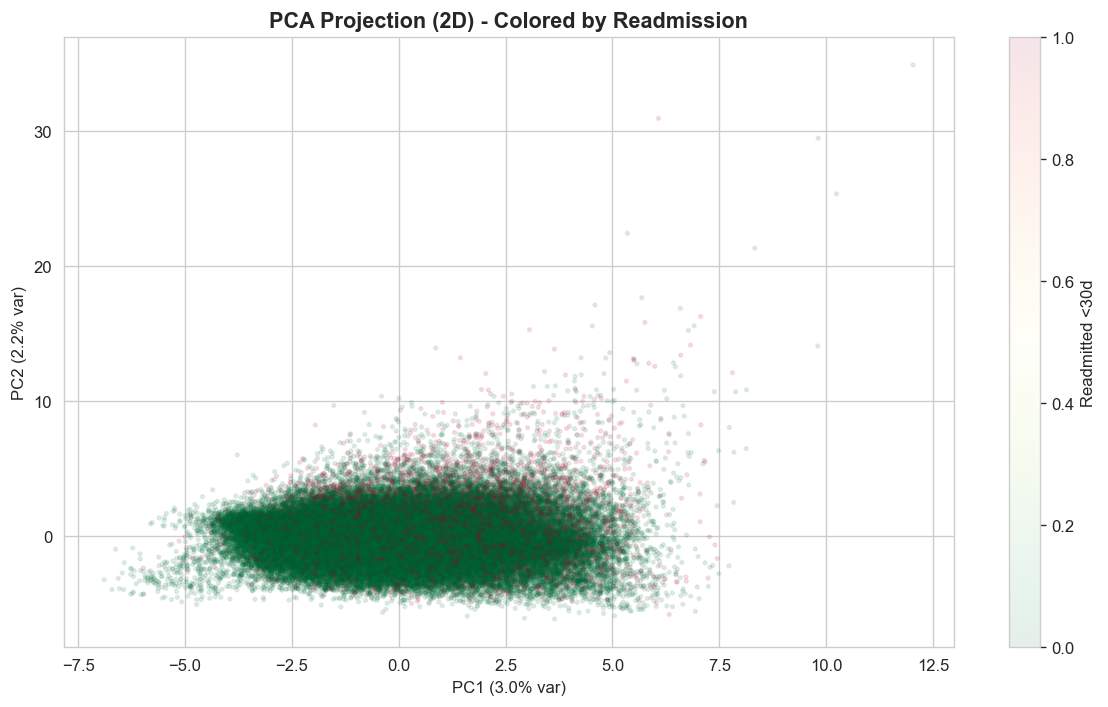


Final feature set: 138 features


In [45]:
# PCA visualization (2D projection)
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_pca)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='RdYlGn_r', alpha=0.1, s=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('PCA Projection (2D) - Colored by Readmission', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Readmitted <30d')
plt.tight_layout()
plt.show()

feature_names = X.columns.tolist()
print(f"\nFinal feature set: {len(feature_names)} features")

---

## Phase 5: Train/Test Split (Patient-Level Grouped)


In [46]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=patient_ids))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = patient_ids.iloc[train_idx]

# Verify zero patient overlap
train_patients = set(patient_ids.iloc[train_idx])
test_patients = set(patient_ids.iloc[test_idx])
overlap = train_patients & test_patients

print(f"Train: {len(X_train):,} encounters ({y_train.mean()*100:.1f}% positive)")
print(f"Test:  {len(X_test):,} encounters ({y_test.mean()*100:.1f}% positive)")
print(f"Train patients: {len(train_patients):,}  |  Test patients: {len(test_patients):,}")
print(f"Patient overlap: {len(overlap)} ← must be 0")

Train: 79,567 encounters (11.4% positive)
Test:  19,773 encounters (11.3% positive)
Train patients: 55,989  |  Test patients: 13,998
Patient overlap: 0 ← must be 0


---

## Phase 6: Baseline Models


In [47]:
# Heuristic Baseline: rank patients by prior inpatient + emergency visits
print("--- Heuristic Baseline: Prior Utilization Ranking ---")
heuristic_score = X_test['number_inpatient'] + X_test['number_emergency']
heuristic_prauc = average_precision_score(y_test, heuristic_score)
heuristic_rocauc = roc_auc_score(y_test, heuristic_score)

K_pct = 0.10
K = int(len(y_test) * K_pct)
heuristic_top_k_idx = heuristic_score.nlargest(K).index
heuristic_recall_at_k = y_test.loc[heuristic_top_k_idx].sum() / y_test.sum()
heuristic_precision_at_k = y_test.loc[heuristic_top_k_idx].mean()
heuristic_lift_at_k = heuristic_precision_at_k / y_test.mean()

print(f"PR-AUC:        {heuristic_prauc:.4f}")
print(f"ROC-AUC:       {heuristic_rocauc:.4f}")
print(f"Recall@10%:    {heuristic_recall_at_k:.4f} ({heuristic_recall_at_k*100:.1f}%)")
print(f"Precision@10%: {heuristic_precision_at_k:.4f}")
print(f"Lift@10%:      {heuristic_lift_at_k:.2f}x")

--- Heuristic Baseline: Prior Utilization Ranking ---
PR-AUC:        0.1817
ROC-AUC:       0.6122
Recall@10%:    0.2210 (22.1%)
Precision@10%: 0.2509
Lift@10%:      2.21x


In [48]:
# Logistic Regression Baseline
print("--- Logistic Regression Baseline ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', solver='lbfgs', C=1.0)
lr.fit(X_train_scaled, y_train)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

lr_prauc = average_precision_score(y_test, lr_probs)
lr_rocauc = roc_auc_score(y_test, lr_probs)
lr_brier = brier_score_loss(y_test, lr_probs)
lr_topk_df = pd.Series(lr_probs, index=X_test.index).nlargest(K)
lr_recall_at_k = y_test.loc[lr_topk_df.index].sum() / y_test.sum()
lr_precision_at_k = y_test.loc[lr_topk_df.index].mean()
lr_lift_at_k = lr_precision_at_k / y_test.mean()

print(f"PR-AUC:        {lr_prauc:.4f}")
print(f"ROC-AUC:       {lr_rocauc:.4f}")
print(f"Brier Score:   {lr_brier:.4f}")
print(f"Recall@10%:    {lr_recall_at_k:.4f}")
print(f"Lift@10%:      {lr_lift_at_k:.2f}x")

--- Logistic Regression Baseline ---
PR-AUC:        0.2243
ROC-AUC:       0.6710
Brier Score:   0.2250
Recall@10%:    0.2299
Lift@10%:      2.30x


---

## Phase 7: SOTA Supervised Learning (5-Fold CV)


In [49]:
# Cross-validation helper
n_folds = 5
sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=42)

def cross_validate_model(model, X_data, y_data, groups, model_name, needs_scaling=False):
    fold_metrics = []
    for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X_data, y_data, groups)):
        X_tr, X_val = X_data.iloc[tr_idx], X_data.iloc[val_idx]
        y_tr, y_val = y_data.iloc[tr_idx], y_data.iloc[val_idx]
        if needs_scaling:
            sc = StandardScaler()
            X_tr = pd.DataFrame(sc.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
            X_val = pd.DataFrame(sc.transform(X_val), columns=X_val.columns, index=X_val.index)
        model.fit(X_tr, y_tr)
        probs = model.predict_proba(X_val)[:, 1]
        fold_metrics.append({
            'fold': fold+1,
            'pr_auc': average_precision_score(y_val, probs),
            'roc_auc': roc_auc_score(y_val, probs),
            'brier': brier_score_loss(y_val, probs)
        })
    metrics_df = pd.DataFrame(fold_metrics)
    print(f"\n{model_name} - {n_folds}-Fold CV:")
    print(f"  PR-AUC:  {metrics_df['pr_auc'].mean():.4f} ± {metrics_df['pr_auc'].std():.4f}")
    print(f"  ROC-AUC: {metrics_df['roc_auc'].mean():.4f} ± {metrics_df['roc_auc'].std():.4f}")
    print(f"  Brier:   {metrics_df['brier'].mean():.4f} ± {metrics_df['brier'].std():.4f}")
    return metrics_df

In [50]:
# Logistic Regression CV
lr_cv = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', solver='lbfgs')
lr_cv_metrics = cross_validate_model(lr_cv, X_train, y_train, groups_train, "Logistic Regression", needs_scaling=True)


Logistic Regression - 5-Fold CV:
  PR-AUC:  0.2107 ± 0.0080
  ROC-AUC: 0.6608 ± 0.0035
  Brier:   0.2264 ± 0.0010


In [51]:
# Random Forest CV
rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=20,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf_cv_metrics = cross_validate_model(rf, X_train, y_train, groups_train, "Random Forest")


Random Forest - 5-Fold CV:
  PR-AUC:  0.2101 ± 0.0073
  ROC-AUC: 0.6629 ± 0.0050
  Brier:   0.2164 ± 0.0002


In [52]:
# XGBoost CV
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos:.1f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos,
    eval_metric='aucpr', random_state=42, n_jobs=-1, reg_alpha=0.1, reg_lambda=1.0
)
xgb_cv_metrics = cross_validate_model(xgb_model, X_train, y_train, groups_train, "XGBoost")

scale_pos_weight: 7.8

XGBoost - 5-Fold CV:
  PR-AUC:  0.2165 ± 0.0068
  ROC-AUC: 0.6567 ± 0.0036
  Brier:   0.1951 ± 0.0008


In [53]:
# LightGBM CV
lgb_model = lgb.LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos,
    random_state=42, n_jobs=-1, verbose=-1, reg_alpha=0.1, reg_lambda=1.0
)
lgb_cv_metrics = cross_validate_model(lgb_model, X_train, y_train, groups_train, "LightGBM")


LightGBM - 5-Fold CV:
  PR-AUC:  0.2238 ± 0.0087
  ROC-AUC: 0.6633 ± 0.0039
  Brier:   0.2039 ± 0.0009


In [54]:
# Stacking Ensemble
print("Training Stacking Ensemble...")
stacking = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=10,
                                       class_weight='balanced', random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                    scale_pos_weight=scale_pos, eval_metric='aucpr',
                                    random_state=42, n_jobs=-1, verbosity=0)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3, passthrough=False, n_jobs=-1
)
stacking.fit(X_train, y_train)
stacking_probs = stacking.predict_proba(X_test)[:, 1]
print(f"Stacking PR-AUC:  {average_precision_score(y_test, stacking_probs):.4f}")
print(f"Stacking ROC-AUC: {roc_auc_score(y_test, stacking_probs):.4f}")

Training Stacking Ensemble...
Stacking PR-AUC:  0.2359
Stacking ROC-AUC: 0.6800


---

## Phase 8: Final Model Training & Test Evaluation


In [55]:
# Train all final models on full training set
print("Training final models on full training set...")

lr_final = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', solver='lbfgs')
lr_final.fit(X_train_scaled, y_train)
lr_test_probs = lr_final.predict_proba(X_test_scaled)[:, 1]

rf_final = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=20,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)
rf_test_probs = rf_final.predict_proba(X_test)[:, 1]

xgb_final = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos,
    eval_metric='aucpr', random_state=42, n_jobs=-1, reg_alpha=0.1, reg_lambda=1.0
)
xgb_final.fit(X_train, y_train)
xgb_test_probs = xgb_final.predict_proba(X_test)[:, 1]

lgb_final = lgb.LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos,
    random_state=42, n_jobs=-1, verbose=-1, reg_alpha=0.1, reg_lambda=1.0
)
lgb_final.fit(X_train, y_train)
lgb_test_probs = lgb_final.predict_proba(X_test)[:, 1]

print("All models trained.")

Training final models on full training set...
All models trained.


In [56]:

# Comprehensive evaluation
def evaluate_model(name, y_true, probs, K):
    probs = np.array(probs, dtype=float)
    # Normalize to [0, 1] if needed (e.g. raw heuristic counts)
    if probs.max() > 1 or probs.min() < 0:
        probs = (probs - probs.min()) / (probs.max() - probs.min())
    prauc = average_precision_score(y_true, probs)
    rocauc = roc_auc_score(y_true, probs)
    brier = brier_score_loss(y_true, probs)
    topk_idx = pd.Series(probs, index=y_true.index).nlargest(K).index
    recall_k = y_true.loc[topk_idx].sum() / y_true.sum()
    precision_k = y_true.loc[topk_idx].mean()
    lift_k = precision_k / y_true.mean()
    return {'Model': name, 'PR-AUC': prauc, 'ROC-AUC': rocauc, 'Brier': brier,
            'Recall@10%': recall_k, 'Precision@10%': precision_k, 'Lift@10%': lift_k}

results = [
    evaluate_model('Heuristic', y_test, heuristic_score.values.astype(float), K),
    evaluate_model('Logistic Regression', y_test, lr_test_probs, K),
    evaluate_model('Random Forest', y_test, rf_test_probs, K),
    evaluate_model('XGBoost', y_test, xgb_test_probs, K),
    evaluate_model('LightGBM', y_test, lgb_test_probs, K),
    evaluate_model('Stacking', y_test, stacking_probs, K),
]
results_df = pd.DataFrame(results).round(4)

print("\n" + "="*70)
print("MODEL COMPARISON - TEST SET")
print("="*70)
print(results_df.to_string(index=False))

best_model_name = results_df.loc[results_df['PR-AUC'].idxmax(), 'Model']
print(f"\n★ Best model by PR-AUC: {best_model_name}")



MODEL COMPARISON - TEST SET
              Model  PR-AUC  ROC-AUC  Brier  Recall@10%  Precision@10%  Lift@10%
          Heuristic  0.1817   0.6122 0.1041      0.2210         0.2509    2.2107
Logistic Regression  0.2243   0.6710 0.2250      0.2299         0.2610    2.2998
      Random Forest  0.2239   0.6707 0.2158      0.2268         0.2575    2.2686
            XGBoost  0.2351   0.6685 0.1968      0.2567         0.2914    2.5672
           LightGBM  0.2373   0.6731 0.2043      0.2602         0.2954    2.6029
           Stacking  0.2359   0.6800 0.0955      0.2442         0.2772    2.4424

★ Best model by PR-AUC: LightGBM


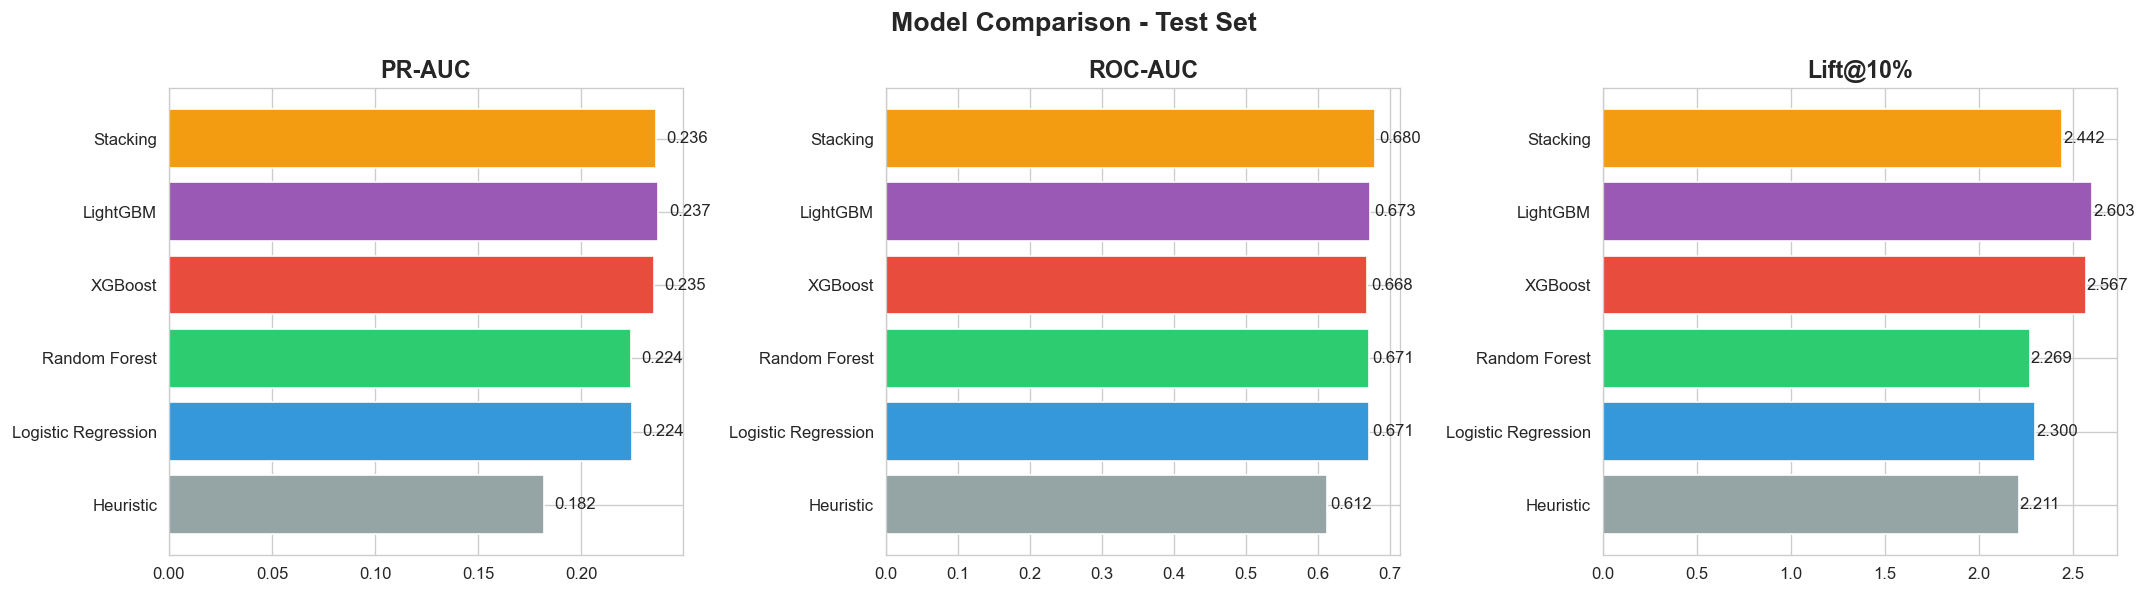

In [57]:
# Model comparison plot
model_map = {'XGBoost': (xgb_final, xgb_test_probs), 'LightGBM': (lgb_final, lgb_test_probs),
             'Random Forest': (rf_final, rf_test_probs), 'Logistic Regression': (lr_final, lr_test_probs),
             'Stacking': (stacking, stacking_probs)}
best_model, best_probs = model_map.get(best_model_name, (xgb_final, xgb_test_probs))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['PR-AUC', 'ROC-AUC', 'Lift@10%']
colors = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
for i, metric in enumerate(metrics_to_plot):
    bars = axes[i].barh(results_df['Model'], results_df[metric], color=colors)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)
plt.suptitle('Model Comparison - Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Phase 9: ROC & Precision-Recall Curves


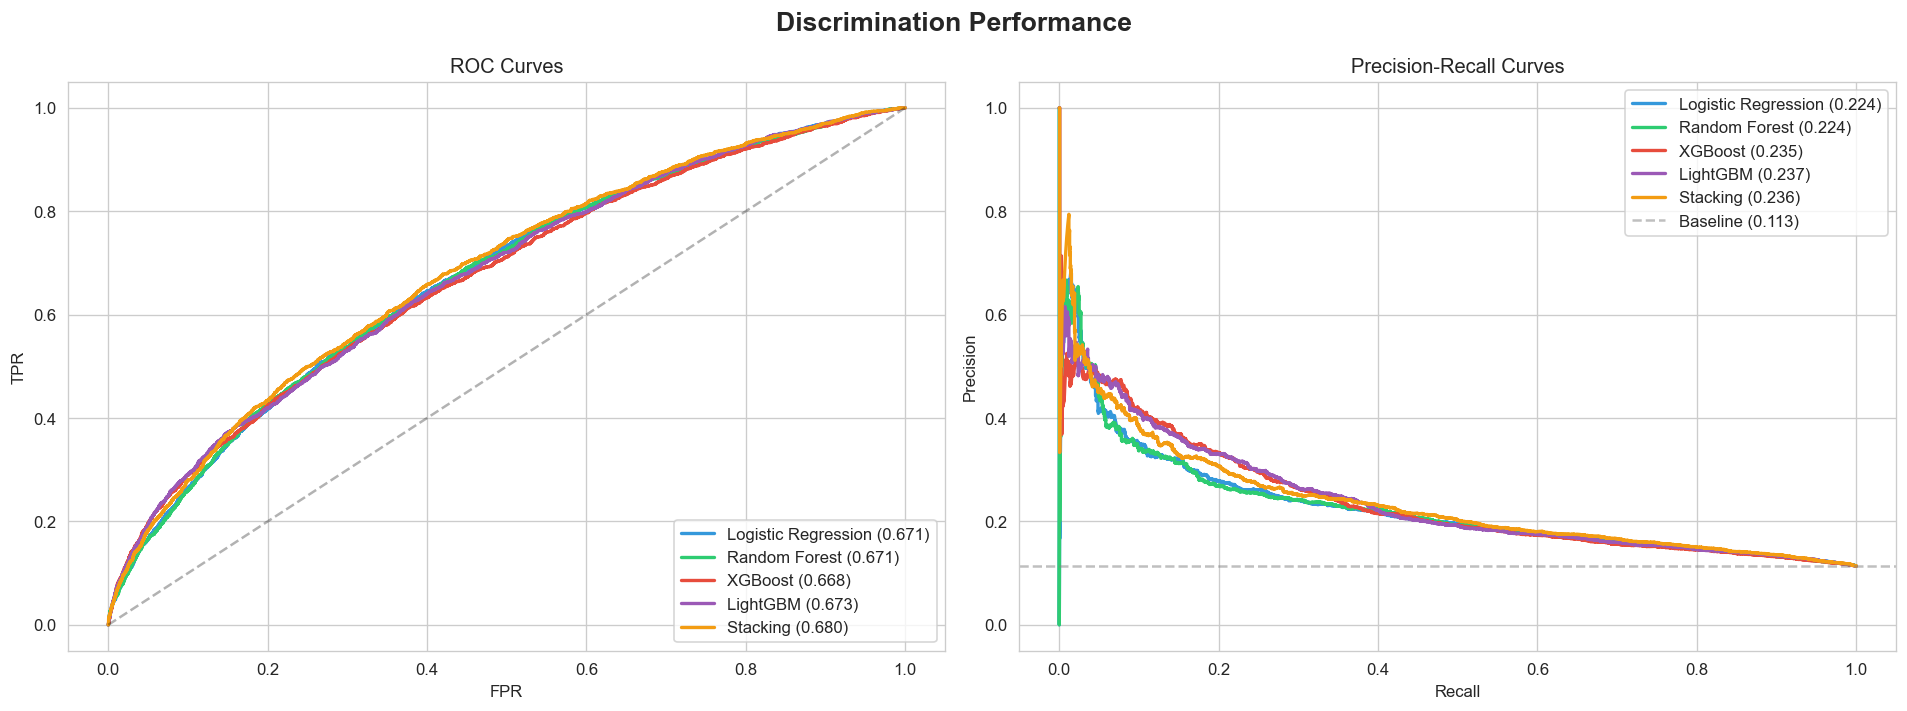

In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
model_probs = {'Logistic Regression': lr_test_probs, 'Random Forest': rf_test_probs,
               'XGBoost': xgb_test_probs, 'LightGBM': lgb_test_probs, 'Stacking': stacking_probs}
plot_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

for (name, probs), color in zip(model_probs.items(), plot_colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax1.plot(fpr, tpr, label=f'{name} ({roc_auc_score(y_test, probs):.3f})', color=color, lw=2)
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ax2.plot(rec, prec, label=f'{name} ({average_precision_score(y_test, probs):.3f})', color=color, lw=2)

ax1.plot([0,1], [0,1], 'k--', alpha=0.3); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curves'); ax1.legend(loc='lower right')
ax2.axhline(y=y_test.mean(), color='gray', ls='--', alpha=0.5, label=f'Baseline ({y_test.mean():.3f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves'); ax2.legend(loc='upper right')
plt.suptitle('Discrimination Performance', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Phase 10: Probability Calibration


Calibrating LightGBM with isotonic regression...


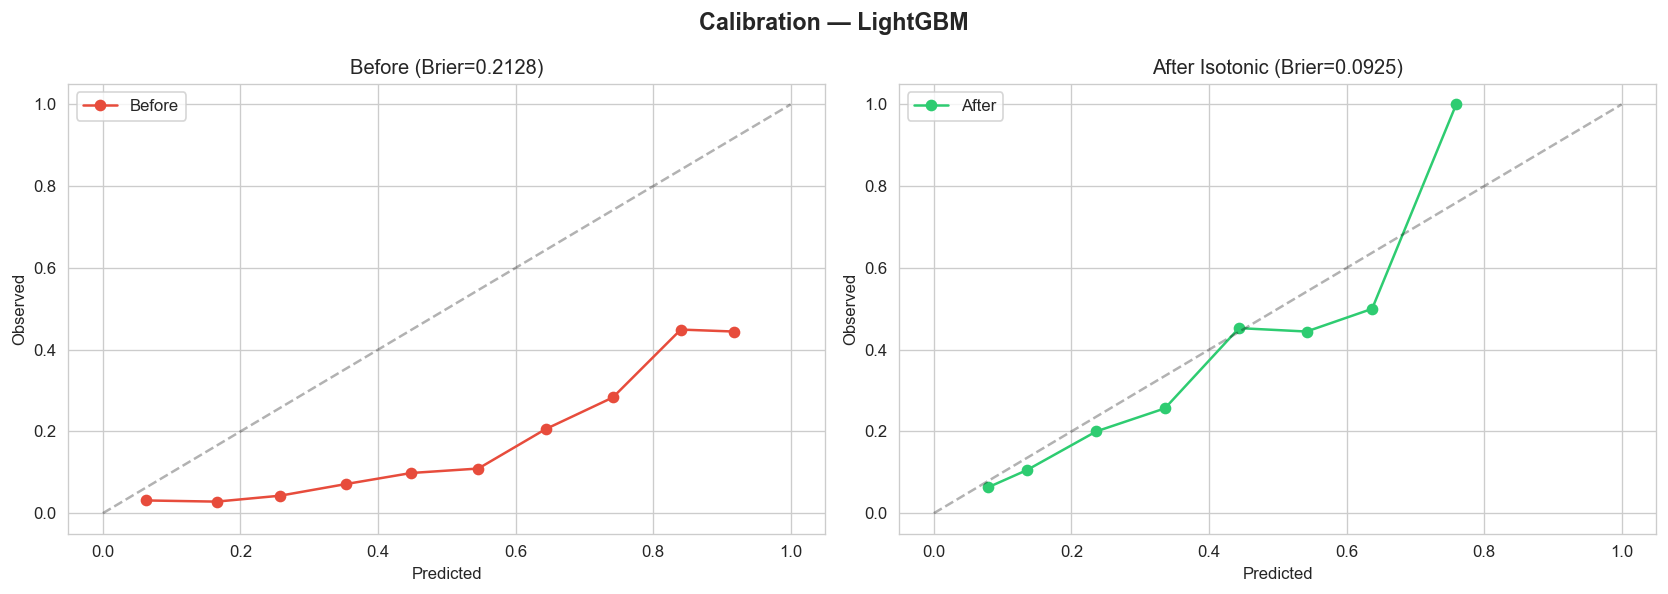

Brier: 0.2128 → 0.0925


In [59]:
# Split test into calibration and evaluation halves
cal_split = int(len(X_test) * 0.5)
X_cal, X_eval = X_test.iloc[:cal_split], X_test.iloc[cal_split:]
y_cal, y_eval = y_test.iloc[:cal_split], y_test.iloc[cal_split:]
probs_cal = best_probs[:cal_split]
probs_eval = best_probs[cal_split:]

# Isotonic calibration
print(f"Calibrating {best_model_name} with isotonic regression...")
cal_model = CalibratedClassifierCV(best_model, method='isotonic', cv=None)
cal_model.fit(X_cal, y_cal)
cal_probs_eval = cal_model.predict_proba(X_eval)[:, 1]

brier_before = brier_score_loss(y_eval, probs_eval)
brier_after = brier_score_loss(y_eval, cal_probs_eval)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
pt_b, pp_b = calibration_curve(y_eval, probs_eval, n_bins=10)
ax1.plot(pp_b, pt_b, 'o-', color='#e74c3c', label='Before'); ax1.plot([0,1],[0,1],'k--',alpha=0.3)
ax1.set_title(f'Before (Brier={brier_before:.4f})'); ax1.legend()
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Observed')

pt_a, pp_a = calibration_curve(y_eval, cal_probs_eval, n_bins=10)
ax2.plot(pp_a, pt_a, 'o-', color='#2ecc71', label='After'); ax2.plot([0,1],[0,1],'k--',alpha=0.3)
ax2.set_title(f'After Isotonic (Brier={brier_after:.4f})'); ax2.legend()
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Observed')

plt.suptitle(f'Calibration — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Brier: {brier_before:.4f} → {brier_after:.4f}")

---

## Phase 11: Explainability (SHAP)


Computing SHAP values for LightGBM...


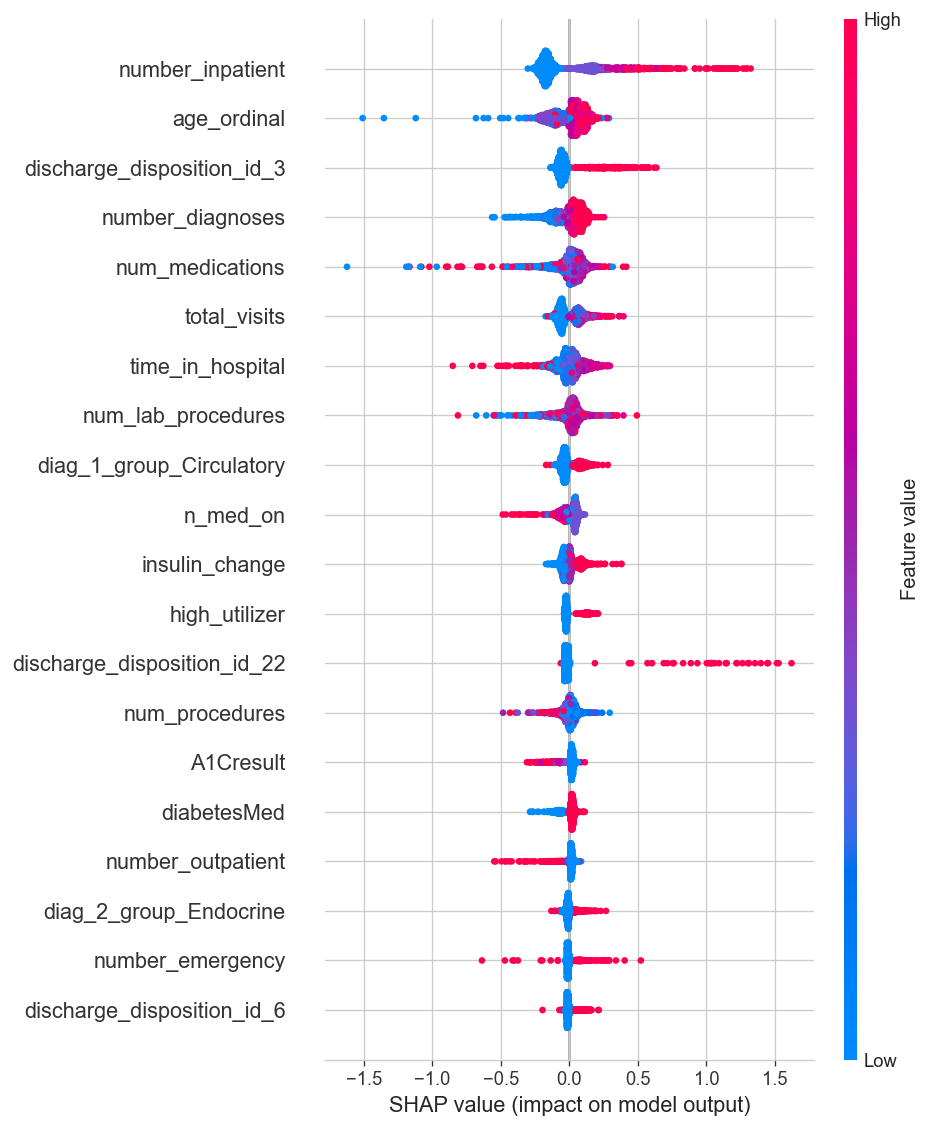

In [60]:
# SHAP global explanations
shap_model = best_model if best_model_name in ['XGBoost','LightGBM','Random Forest'] else xgb_final
print(f"Computing SHAP values for {best_model_name}...")
explainer = shap.TreeExplainer(shap_model)

shap_sample_size = min(2000, len(X_test))
X_shap_sample = X_test.sample(shap_sample_size, random_state=42)
shap_values = explainer.shap_values(X_shap_sample)

shap.summary_plot(shap_values, X_shap_sample, max_display=20, show=True)

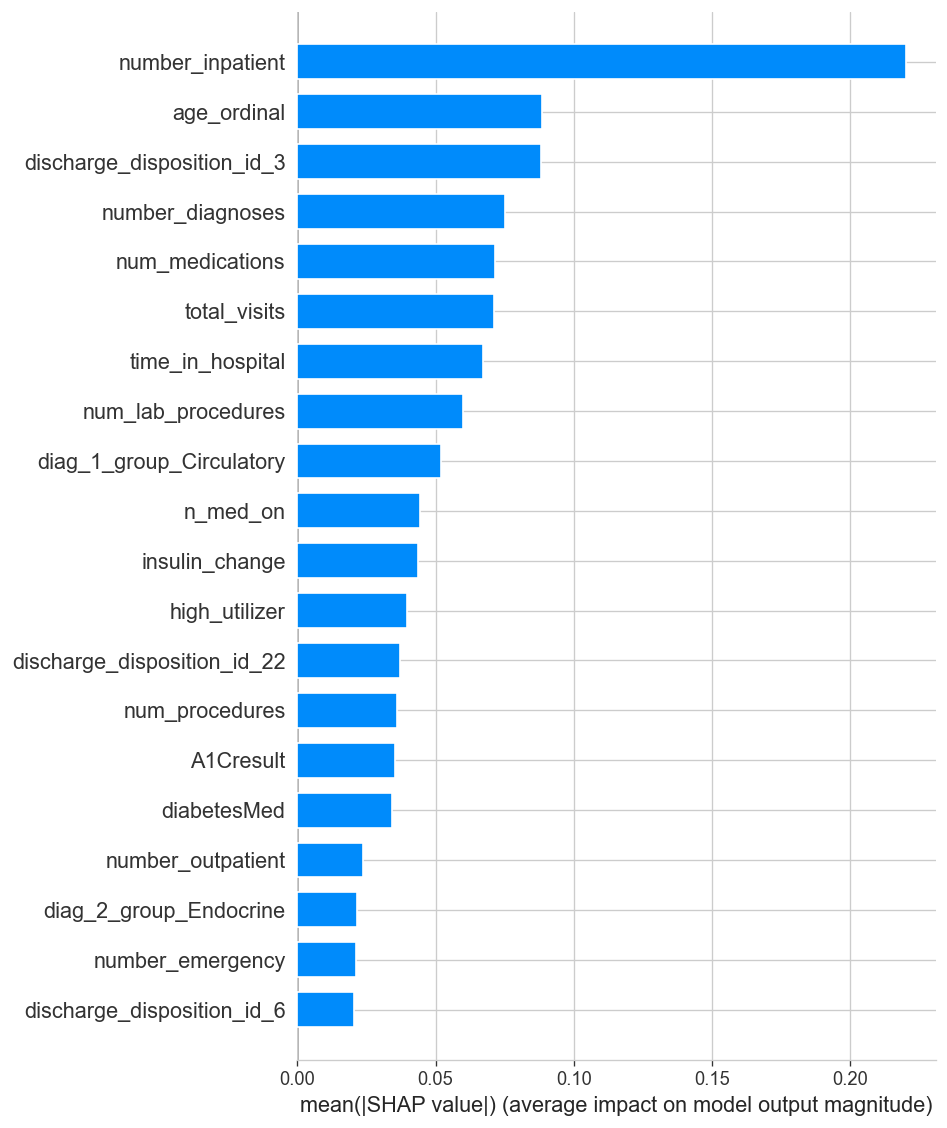

In [61]:
# SHAP bar plot (mean absolute values)
shap.summary_plot(shap_values, X_shap_sample, plot_type='bar', max_display=20, show=True)


High Risk Patient — P(readmit<30d) = 0.941


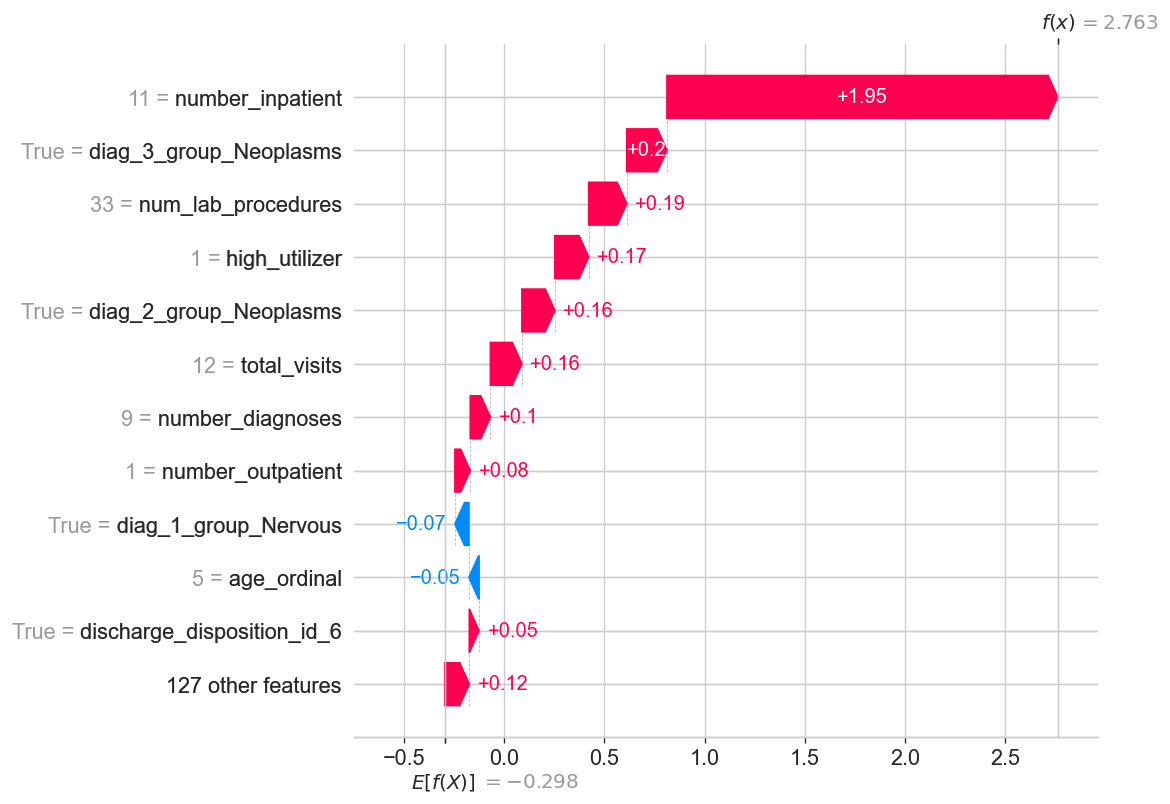


Medium Risk Patient — P(readmit<30d) = 0.422


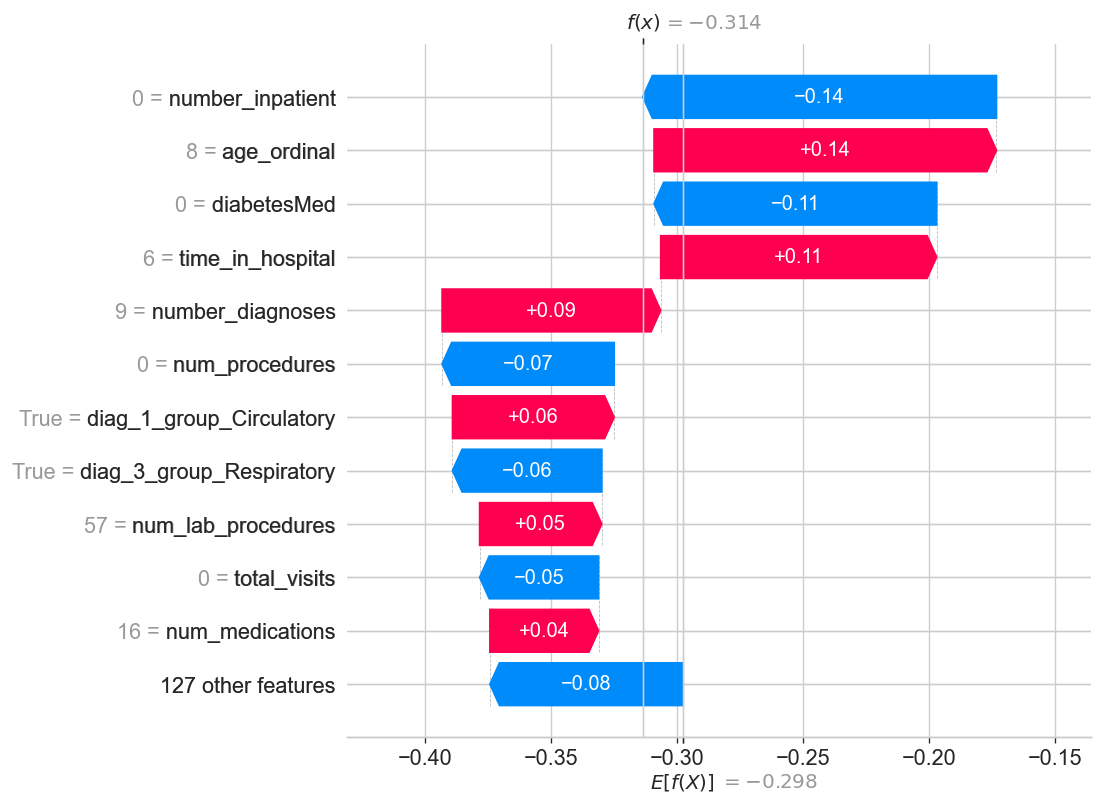


Low Risk Patient — P(readmit<30d) = 0.010


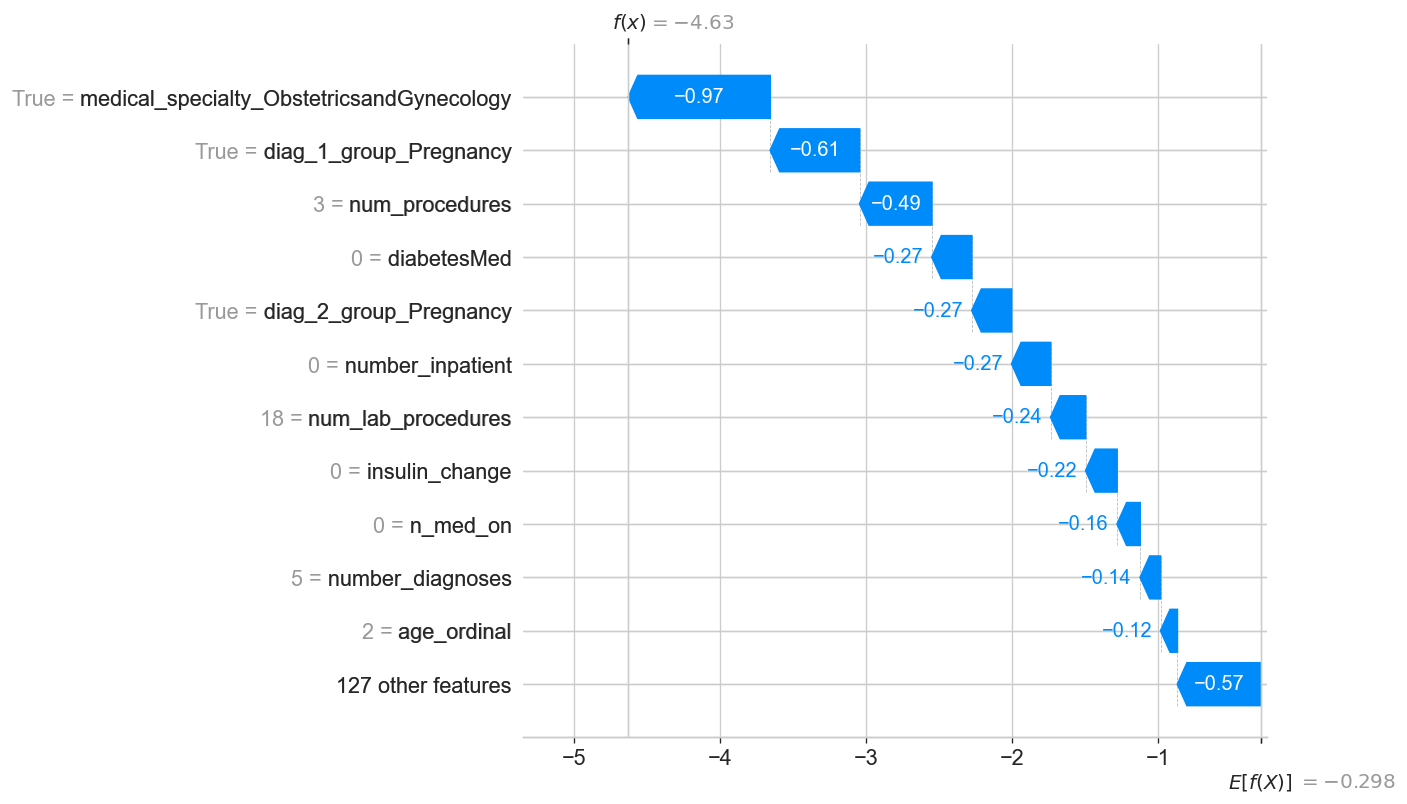

In [62]:
# Per-patient waterfall examples (high, medium, low risk)
probs_series = pd.Series(best_probs, index=X_test.index)
high_risk_idx = probs_series.idxmax()
low_risk_idx = probs_series.idxmin()
medium_risk_idx = (probs_series - probs_series.median()).abs().idxmin()

for label, idx in [('High Risk', high_risk_idx), ('Medium Risk', medium_risk_idx), ('Low Risk', low_risk_idx)]:
    patient_row = X_test.loc[[idx]]
    sv = explainer.shap_values(patient_row)
    patient_prob = probs_series.loc[idx]
    print(f"\n{label} Patient — P(readmit<30d) = {patient_prob:.3f}")
    shap.waterfall_plot(
        shap.Explanation(values=sv[0], base_values=explainer.expected_value,
                         data=patient_row.values[0], feature_names=feature_names),
        max_display=12, show=True
    )

---

## Phase 12: Fairness Audit


In [63]:
# Reconstruct race from one-hot columns
race_cols = [c for c in X_test.columns if c.startswith('race_')]
test_race = pd.DataFrame(X_test[race_cols])
test_race['race'] = 'Caucasian'  # reference category
for col in race_cols:
    test_race.loc[test_race[col] == 1, 'race'] = col.replace('race_', '')
test_race['y_true'] = y_test.values
test_race['y_prob'] = best_probs

print(f"{'Race Group':<20} {'N':>6} {'Base Rate':>10} {'ROC-AUC':>9} {'PR-AUC':>8} {'Recall@10%':>11}")
print("-" * 70)

fairness_results = []
for race in sorted(test_race['race'].unique()):
    subset = test_race[test_race['race'] == race]
    n = len(subset)
    if n < 50 or subset['y_true'].sum() < 5: continue
    br = subset['y_true'].mean()
    ra = roc_auc_score(subset['y_true'], subset['y_prob'])
    pa = average_precision_score(subset['y_true'], subset['y_prob'])
    k_sub = max(1, int(n * 0.10))
    topk = subset.nlargest(k_sub, 'y_prob')
    rec_k = topk['y_true'].sum() / max(1, subset['y_true'].sum())
    print(f"{race:<20} {n:>6} {br:>10.3f} {ra:>9.4f} {pa:>8.4f} {rec_k:>11.4f}")
    fairness_results.append({'race': race, 'n': n, 'roc_auc': ra, 'pr_auc': pa})

pop_roc = roc_auc_score(y_test, best_probs)
print(f"\nPopulation ROC-AUC: {pop_roc:.4f}")
fairness_df = pd.DataFrame(fairness_results)
gap = fairness_df['roc_auc'].min() - pop_roc
print(f"Max subgroup gap: {gap:.4f} {'⚠ FLAG' if abs(gap) > 0.05 else '✓ OK'}")

Race Group                N  Base Rate   ROC-AUC   PR-AUC  Recall@10%
----------------------------------------------------------------------
Asian                   116      0.086    0.6736   0.1634      0.2000
Caucasian             18510      0.115    0.6709   0.2382      0.2567
Hispanic                398      0.090    0.7548   0.3406      0.3611
Other                   302      0.103    0.6804   0.2584      0.2903
Unknown                 447      0.072    0.6437   0.1533      0.2812

Population ROC-AUC: 0.6731
Max subgroup gap: -0.0294 ✓ OK


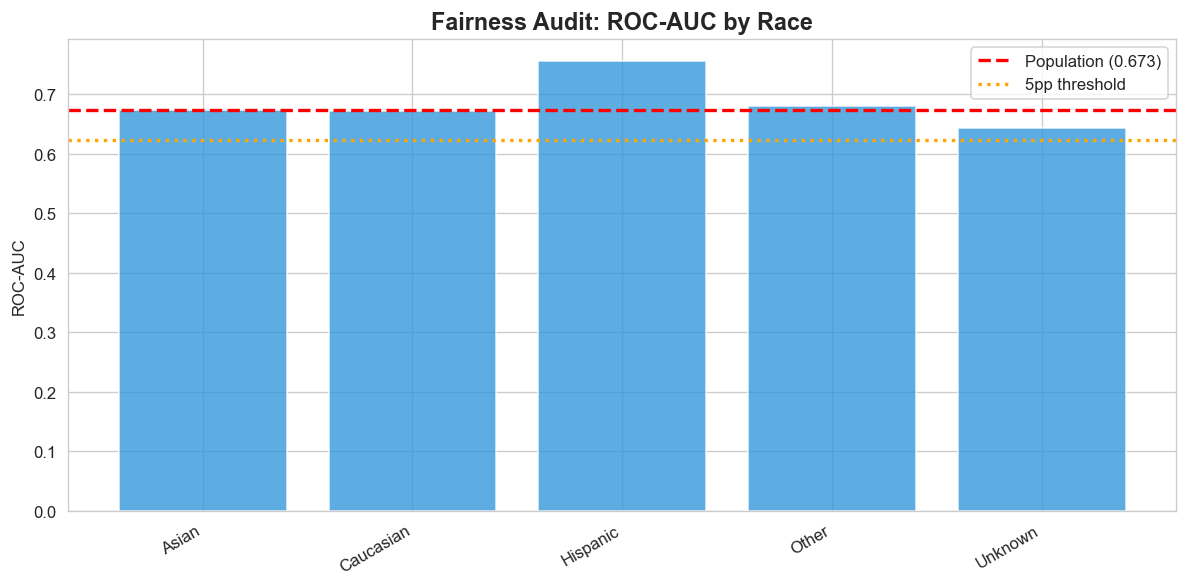

In [64]:
# Fairness bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(fairness_df)), fairness_df['roc_auc'], color='#3498db', alpha=0.8)
ax.axhline(y=pop_roc, color='red', ls='--', lw=2, label=f'Population ({pop_roc:.3f})')
ax.axhline(y=pop_roc - 0.05, color='orange', ls=':', lw=2, label='5pp threshold')
ax.set_xticks(range(len(fairness_df)))
ax.set_xticklabels(fairness_df['race'], rotation=30, ha='right')
ax.set_ylabel('ROC-AUC'); ax.set_title('Fairness Audit: ROC-AUC by Race', fontsize=14, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

---

## Phase 13: Operational Outputs (Risk Tiers + Top-K Outreach)


In [65]:
# Risk tier assignment
p15 = np.percentile(best_probs, 15)
p85 = np.percentile(best_probs, 85)
print(f"Tier thresholds: Low < {p15:.4f} | Medium {p15:.4f}–{p85:.4f} | High > {p85:.4f}")

def assign_tier(prob):
    if prob >= p85: return 'High'
    elif prob >= p15: return 'Medium'
    else: return 'Low'

# Generate per-patient explanations
print("\nGenerating per-patient SHAP explanations (top 500)...")
explanation_sample = X_test.head(500)
sv_explain = explainer.shap_values(explanation_sample)

def get_top_reasons(shap_row, feature_names, top_n=3):
    top_idx = np.abs(shap_row).argsort()[-top_n:][::-1]
    return " | ".join([f"{feature_names[i]} ({'↑' if shap_row[i]>0 else '↓'})" for i in top_idx])

output_data = []
for i in range(len(explanation_sample)):
    idx = explanation_sample.index[i]
    prob = probs_series.loc[idx]
    output_data.append({
        'risk_probability': round(prob, 4),
        'risk_tier': assign_tier(prob),
        'top_3_reasons': get_top_reasons(sv_explain[i], feature_names)
    })

output_df = pd.DataFrame(output_data).sort_values('risk_probability', ascending=False)
print(f"\n--- Top 10 Highest-Risk Patients ---")
output_df.head(10)

Tier thresholds: Low < 0.2762 | Medium 0.2762–0.5911 | High > 0.5911

Generating per-patient SHAP explanations (top 500)...

--- Top 10 Highest-Risk Patients ---


,risk_probability,risk_tier,top_3_reasons
319,0.8497,High,number_inpatient (↑) | diag_2_group_Endocrine ...
85,0.8315,High,number_inpatient (↑) | diag_3_group_Neoplasms ...
380,0.8257,High,discharge_disposition_id_2 (↑) | diag_1_group_...
247,0.7833,High,number_inpatient (↑) | diag_2_group_Neoplasms ...
268,0.7602,High,number_inpatient (↑) | high_utilizer (↑) | tot...
262,0.7539,High,discharge_disposition_id_5 (↑) | number_inpati...
427,0.7373,High,discharge_disposition_id_3 (↑) | admission_typ...
269,0.7301,High,number_inpatient (↑) | diag_2_group_Neoplasms ...
467,0.7280,High,number_inpatient (↑) | diag_1_group_Endocrine ...
225,0.7266,High,number_inpatient (↑) | high_utilizer (↑) | tot...


---

## Phase 14: Confusion Matrix & Classification Report


Threshold (top 10%): 0.6335

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.91      0.92      0.91     17529
    Readmitted       0.30      0.26      0.28      2244

      accuracy                           0.85     19773
     macro avg       0.60      0.59      0.60     19773
  weighted avg       0.84      0.85      0.84     19773



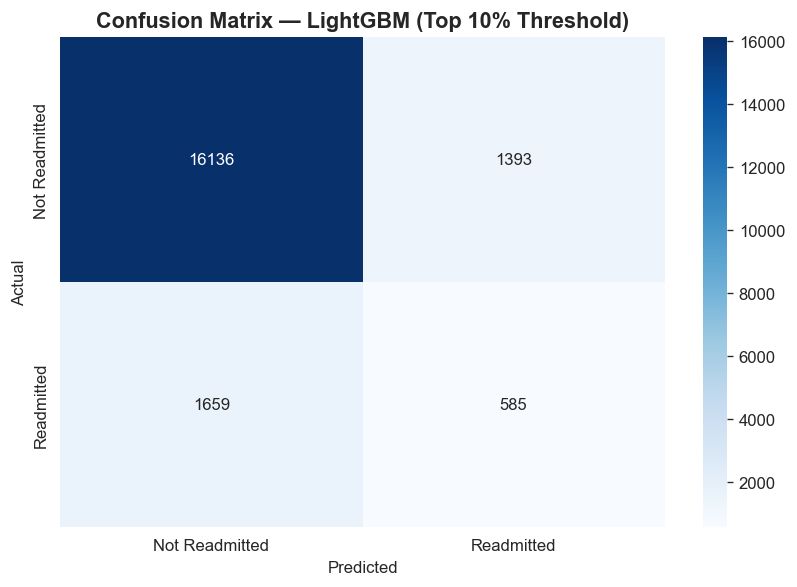

In [66]:
# At the top-10% threshold
threshold = np.percentile(best_probs, 90)
y_pred_topk = (best_probs >= threshold).astype(int)

print(f"Threshold (top 10%): {threshold:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_topk, target_names=['Not Readmitted', 'Readmitted']))

cm = confusion_matrix(y_test, y_pred_topk)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_model_name} (Top 10% Threshold)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Phase 15: Cumulative Gains & Lift Chart


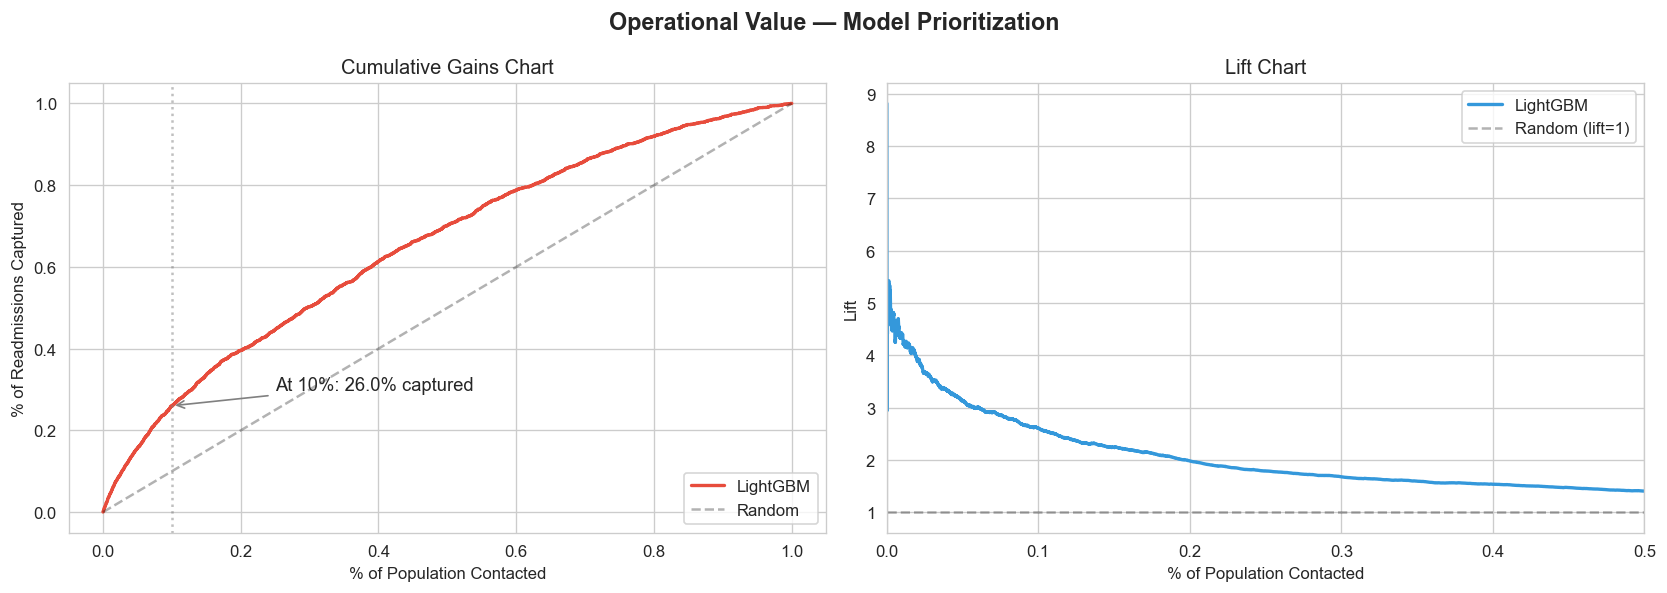

In [67]:
sorted_idx = np.argsort(-best_probs)
sorted_y = y_test.values[sorted_idx]
cumulative_gains = np.cumsum(sorted_y) / sorted_y.sum()
pct_population = np.arange(1, len(sorted_y) + 1) / len(sorted_y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(pct_population, cumulative_gains, color='#e74c3c', lw=2, label=best_model_name)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax1.set_xlabel('% of Population Contacted'); ax1.set_ylabel('% of Readmissions Captured')
ax1.set_title('Cumulative Gains Chart'); ax1.legend()
ax1.axvline(x=0.10, color='gray', ls=':', alpha=0.5)
gains_at_10 = cumulative_gains[int(0.10*len(cumulative_gains))-1]
ax1.annotate(f'At 10%: {gains_at_10*100:.1f}% captured', xy=(0.10, gains_at_10),
             xytext=(0.25, 0.3), fontsize=11, arrowprops=dict(arrowstyle='->', color='gray'))

lift = cumulative_gains / pct_population
ax2.plot(pct_population, lift, color='#3498db', lw=2, label=best_model_name)
ax2.axhline(y=1, color='k', ls='--', alpha=0.3, label='Random (lift=1)')
ax2.set_xlabel('% of Population Contacted'); ax2.set_ylabel('Lift')
ax2.set_title('Lift Chart'); ax2.legend(); ax2.set_xlim(0, 0.5)

plt.suptitle('Operational Value — Model Prioritization', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Final Summary


In [69]:
print("="*70)
print("  FINAL SUMMARY")
print("="*70)

print(f"""
PROJECT: 30-Day Readmission Risk Prediction for Diabetic Patients
DATASET: UCI Diabetes 130-US Hospitals | {len(df_encoded):,} encounters
TARGET:  Binary (readmitted <30 days) | {y.mean()*100:.1f}% positive rate
SPLIT:   Patient-level grouped | Train: {len(X_train):,} | Test: {len(X_test):,}
BEST MODEL: {best_model_name}
""")

print(results_df.to_string(index=False))

print("PIPELINE COMPLETE ✓")

  FINAL SUMMARY

PROJECT: 30-Day Readmission Risk Prediction for Diabetic Patients
DATASET: UCI Diabetes 130-US Hospitals | 99,340 encounters
TARGET:  Binary (readmitted <30 days) | 11.4% positive rate
SPLIT:   Patient-level grouped | Train: 79,567 | Test: 19,773
BEST MODEL: LightGBM

              Model  PR-AUC  ROC-AUC  Brier  Recall@10%  Precision@10%  Lift@10%
          Heuristic  0.1817   0.6122 0.1041      0.2210         0.2509    2.2107
Logistic Regression  0.2243   0.6710 0.2250      0.2299         0.2610    2.2998
      Random Forest  0.2239   0.6707 0.2158      0.2268         0.2575    2.2686
            XGBoost  0.2351   0.6685 0.1968      0.2567         0.2914    2.5672
           LightGBM  0.2373   0.6731 0.2043      0.2602         0.2954    2.6029
           Stacking  0.2359   0.6800 0.0955      0.2442         0.2772    2.4424
PIPELINE COMPLETE ✓
